In [ ]:
!pip install datasets accelerate scikit-learn evaluate
!pip install -U transformers
!pip install tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [1]:
from datasets import load_dataset
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer, BertTokenizer,
    DataCollatorWithPadding, TrainingArguments, Trainer 
)
from peft import LoraConfig, TaskType, get_peft_model
import numpy as np
import evaluate

train_dataset = load_dataset("ccdv/arxiv-classification", split='train')
valid_dataset = load_dataset("ccdv/arxiv-classification", split='validation')
test_dataset = load_dataset("ccdv/arxiv-classification", split='test')
print(train_dataset)
print(valid_dataset)
print(test_dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/218M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/214M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/74.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28388 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 28388
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2500
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2500
})


In [2]:
print(train_dataset[0])

{'text': 'Constrained Submodular Maximization via a\nNon-symmetric Technique\n\narXiv:1611.03253v1 [cs.DS] 10 Nov 2016\n\nNiv Buchbinder∗\n\nMoran Feldman†\n\nNovember 11, 2016\n\nAbstract\nThe study of combinatorial optimization problems with a submodular objective has attracted\nmuch attention in recent years. Such problems are important in both theory and practice because\ntheir objective functions are very general. Obtaining further improvements for many submodular\nmaximization problems boils down to finding better algorithms for optimizing a relaxation of\nthem known as the multilinear extension.\nIn this work we present an algorithm for optimizing the multilinear relaxation whose guarantee improves over the guarantee of the best previous algorithm (which was given by Ene\nand Nguyen (2016)). Moreover, our algorithm is based on a new technique which is, arguably,\nsimpler and more natural for the problem at hand. In a nutshell, previous algorithms for this\nproblem rely on symmet

In [3]:
id2label = {
    0: "math.AC",
    1: "cs.CV",
    2: "cs.AI",
    3: "cs.SY",
    4: "math.GR",
    5: "cs.CE",
    6: "cs.PL",
    7: "cs.IT",
    8: "cs.DS",
    9: "cs.NE",
    10: "math.ST"
}
label2id = {
    "math.AC": 0,
    "cs.CV": 1,
    "cs.AI": 2,
    "cs.SY": 3,
    "math.GR": 4,
    "cs.CE": 5,
    "cs.PL": 6,
    "cs.IT": 7,
    "cs.DS": 8,
    "cs.NE": 9,
    "math.ST": 10
}

In [6]:
BATCH_SIZE = 4
NUM_PROCS = 32
LR = 0.00005
EPOCHS = 3
MODEL = 'bert-base-uncased'
OUT_DIR = 'arxiv_bert'

In [7]:

tokenizer = BertTokenizer.from_pretrained(MODEL)
tokenizer_other = AutoTokenizer.from_pretrained(MODEL)
print(tokenizer)
print(tokenizer_other)

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)
BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_to

In [8]:
def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
    )

In [9]:
tokenized_train = train_dataset.map(
    preprocess_function,
    batched=True,
    batch_size=BATCH_SIZE,
    num_proc=NUM_PROCS
)
 
tokenized_valid = valid_dataset.map(
    preprocess_function,
    batched=True,
    batch_size=BATCH_SIZE,
    num_proc=NUM_PROCS
)
 
tokenized_test = test_dataset.map(
    preprocess_function,
    batched=True,
    batch_size=BATCH_SIZE,
    num_proc=NUM_PROCS
)

Map (num_proc=32):   0%|          | 0/28388 [00:00<?, ? examples/s]

Map (num_proc=32):   0%|          | 0/2500 [00:00<?, ? examples/s]

Map (num_proc=32):   0%|          | 0/2500 [00:00<?, ? examples/s]

In [10]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [11]:
tokenized_sample = preprocess_function(train_dataset[0])
print(tokenized_sample)
print(f"Length of tokenized IDs: {len(tokenized_sample.input_ids)}")
print(f"Length of attention mask: {len(tokenized_sample.attention_mask)}")

{'input_ids': [101, 27570, 4942, 5302, 8566, 8017, 20446, 3989, 3081, 1037, 2512, 1011, 19490, 6028, 12098, 9048, 2615, 1024, 28769, 1012, 6021, 17788, 2509, 2615, 2487, 1031, 20116, 1012, 16233, 1033, 2184, 13292, 2355, 9152, 2615, 20934, 2818, 8428, 4063, 30125, 17866, 26908, 1526, 2281, 2340, 1010, 2355, 10061, 1996, 2817, 1997, 22863, 23207, 4818, 20600, 3471, 2007, 1037, 4942, 5302, 8566, 8017, 7863, 2038, 6296, 2172, 3086, 1999, 3522, 2086, 1012, 2107, 3471, 2024, 2590, 1999, 2119, 3399, 1998, 3218, 2138, 2037, 7863, 4972, 2024, 2200, 2236, 1012, 11381, 2582, 8377, 2005, 2116, 4942, 5302, 8566, 8017, 20446, 3989, 3471, 26077, 2015, 2091, 2000, 4531, 2488, 13792, 2005, 23569, 27605, 6774, 1037, 23370, 1997, 2068, 2124, 2004, 1996, 4800, 4179, 2906, 5331, 1012, 1999, 2023, 2147, 2057, 2556, 2019, 9896, 2005, 23569, 27605, 6774, 1996, 4800, 4179, 2906, 23370, 3005, 11302, 24840, 2058, 1996, 11302, 1997, 1996, 2190, 3025, 9896, 1006, 2029, 2001, 2445, 2011, 4372, 2063, 1998, 16577, 1

In [12]:
from transformers import AutoModelForSequenceClassification, BertForSequenceClassification

print('Number of labels:', id2label.__len__()
      )
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=id2label.__len__(),
    id2label=id2label,
    label2id=label2id,
)
print(model.config)

model = BertForSequenceClassification.from_pretrained(MODEL, num_labels=id2label.__len__())
print(model.config)

Number of labels: 11


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "math.AC",
    "1": "cs.CV",
    "2": "cs.AI",
    "3": "cs.SY",
    "4": "math.GR",
    "5": "cs.CE",
    "6": "cs.PL",
    "7": "cs.IT",
    "8": "cs.DS",
    "9": "cs.NE",
    "10": "math.ST"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "cs.AI": 2,
    "cs.CE": 5,
    "cs.CV": 1,
    "cs.DS": 8,
    "cs.IT": 7,
    "cs.NE": 9,
    "cs.PL": 6,
    "cs.SY": 3,
    "math.AC": 0,
    "math.GR": 4,
    "math.ST": 10
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8",
    "9": "LABEL_9",
    "10": "LABEL_10"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_10": 10,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4,
    "LABEL_5": 5,
    "LABEL_6": 6,
    "LABEL_7": 7,
    "LABEL_8": 8,
    "LABEL_9": 9
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,


In [13]:
import evaluate

accuracy = evaluate.load('accuracy')
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

In [14]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=OUT_DIR,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    save_total_limit=3,
    report_to='tensorboard',
    fp16=True,
    metric_for_best_model='eval_eval_loss',
)

In [15]:
from transformers import Trainer
import numpy as np

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset={"train": tokenized_train, "eval": tokenized_valid},
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
 
history = trainer.train()

/home/odysseas/envs/slms/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [15]:
print(trainer.state.log_history)
print(history)

[{'loss': 0.8478968505859374, 'grad_norm': 10.305377960205078, 'learning_rate': 4.4380630630630634e-05, 'epoch': 0.5630630630630631, 'step': 500}, {'eval_train_loss': 0.38306528329849243, 'eval_train_accuracy': 0.8828730449485698, 'eval_train_runtime': 56.0264, 'eval_train_samples_per_second': 506.69, 'eval_train_steps_per_second': 15.85, 'epoch': 1.0, 'step': 888}, {'eval_eval_loss': 0.4526183605194092, 'eval_eval_accuracy': 0.8572, 'eval_eval_runtime': 4.9711, 'eval_eval_samples_per_second': 502.911, 'eval_eval_steps_per_second': 15.892, 'epoch': 1.0, 'step': 888}, {'loss': 0.497328857421875, 'grad_norm': 6.4733991622924805, 'learning_rate': 3.875e-05, 'epoch': 1.1261261261261262, 'step': 1000}, {'loss': 0.3753655395507812, 'grad_norm': 5.0061421394348145, 'learning_rate': 3.3119369369369366e-05, 'epoch': 1.689189189189189, 'step': 1500}, {'eval_train_loss': 0.2636125981807709, 'eval_train_accuracy': 0.917077638438777, 'eval_train_runtime': 56.3097, 'eval_train_samples_per_second': 5

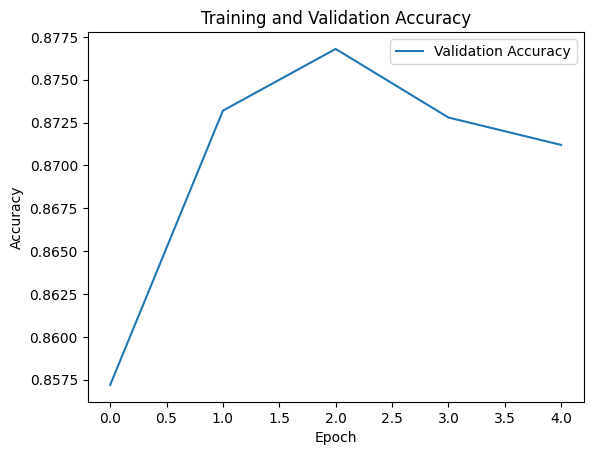

In [16]:
# Plot the training and validation accuracy
import matplotlib.pyplot as plt
train_accuracy = []
eval_accuracy = []

for log in trainer.state.log_history:
    if 'eval_eval_accuracy' in log:
        eval_accuracy.append(log['eval_eval_accuracy'])
    if 'eval_train_accuracy' in log:
        train_accuracy.append(log['eval_train_accuracy'])

plt.plot(eval_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


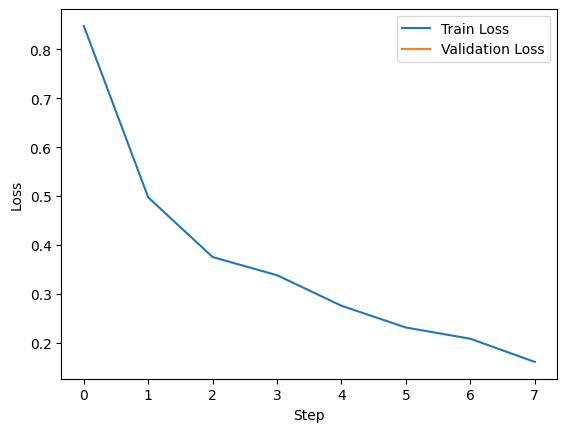

In [17]:
train_loss = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]

plt.plot(train_loss, label='Train Loss')
plt.plot(eval_loss, label='Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [18]:
MODEL = 'answerdotai/ModernBERT-base'

In [19]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)

In [25]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=id2label.__len__(),
    id2label=id2label,
    label2id=label2id,
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=2048,  # or up to 8192, depending on your GPU memory
    )

In [27]:
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    save_total_limit=3,
    report_to='tensorboard',
    bf16=True,
    metric_for_best_model='eval_eval_loss',
)

In [28]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset={"train": tokenized_train, "eval": tokenized_valid},
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
 
history = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Train Loss,Train Accuracy,Eval Loss,Eval Accuracy
1,1.332947,No log,0.582925,0.820135,0.679258,0.792400
2,0.477058,No log,0.349969,0.890306,0.498338,0.835200
3,0.321832,No log,0.218003,0.929372,0.475735,0.846400
4,0.227631,No log,0.152526,0.946280,0.594773,0.838000
5,0.157922,No log,0.113829,0.954946,0.634159,0.836400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [29]:
from peft import LoraConfig, TaskType, get_peft_model

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["Wqkv", "Wo", "Wi"],
    )

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # shows how few params are being trained


trainable params: 1,698,059 || all params: 151,311,382 || trainable%: 1.1222


In [30]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset={"train": tokenized_train, "eval": tokenized_valid},
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
 
history = trainer.train()

Epoch,Training Loss,Validation Loss,Train Loss,Train Accuracy,Eval Loss,Eval Accuracy
1,0.205688,No log,0.183772,0.939024,0.518665,0.843200
2,0.182213,No log,0.171966,0.941701,0.554864,0.841600
3,0.168038,No log,0.166259,0.942758,0.580474,0.841200
4,0.167025,No log,0.158753,0.944413,0.596830,0.841600
5,0.161299,No log,0.156432,0.945118,0.603322,0.839600


In [1]:
from datasets import load_dataset
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer, BertTokenizer,
    DataCollatorWithPadding, TrainingArguments, Trainer 
)
from peft import LoraConfig, TaskType, get_peft_model
import numpy as np
import evaluate

train_dataset = load_dataset("ccdv/arxiv-classification", split='train')
valid_dataset = load_dataset("ccdv/arxiv-classification", split='validation')
test_dataset = load_dataset("ccdv/arxiv-classification", split='test')
print(train_dataset)
print(valid_dataset)
print(test_dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Dataset({
    features: ['text', 'label'],
    num_rows: 28388
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2500
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2500
})


In [7]:
BATCH_SIZE = 16
NUM_PROCS = 32
LR = 0.00005
EPOCHS = 5
MODEL = 'answerdotai/ModernBERT-base'
OUT_DIR = 'arxiv_bert'
MAX_LENGTH = 1024

tokenizer = AutoTokenizer.from_pretrained(MODEL)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def preprocess_function(examples, max_length=MAX_LENGTH):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=max_length,
    )

tokenized_train = train_dataset.map(
    preprocess_function,
    batched=True,
    batch_size=BATCH_SIZE,
    num_proc=NUM_PROCS
)
 
tokenized_valid = valid_dataset.map(
    preprocess_function,
    batched=True,
    batch_size=BATCH_SIZE,
    num_proc=NUM_PROCS
)
 
tokenized_test = test_dataset.map(
    preprocess_function,
    batched=True,
    batch_size=BATCH_SIZE,
    num_proc=NUM_PROCS
)


Map (num_proc=32):   0%|          | 0/28388 [00:00<?, ? examples/s]

Map (num_proc=32):   0%|          | 0/2500 [00:00<?, ? examples/s]

Map (num_proc=32):   0%|          | 0/2500 [00:00<?, ? examples/s]

In [8]:
id2label = {
    0: "math.AC",
    1: "cs.CV",
    2: "cs.AI",
    3: "cs.SY",
    4: "math.GR",
    5: "cs.CE",
    6: "cs.PL",
    7: "cs.IT",
    8: "cs.DS",
    9: "cs.NE",
    10: "math.ST"
}
label2id = {
    "math.AC": 0,
    "cs.CV": 1,
    "cs.AI": 2,
    "cs.SY": 3,
    "math.GR": 4,
    "cs.CE": 5,
    "cs.PL": 6,
    "cs.IT": 7,
    "cs.DS": 8,
    "cs.NE": 9,
    "math.ST": 10
}

In [ ]:

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=id2label.__len__(),
    id2label=id2label,
    label2id=label2id,
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["Wqkv", "Wo", "Wi"],
    )

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  

training_args = TrainingArguments(
    output_dir=OUT_DIR,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    save_total_limit=3,
    report_to='tensorboard',
    bf16=True,
    metric_for_best_model='eval_eval_loss',
)

accuracy = evaluate.load('accuracy')
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset={"train": tokenized_train, "eval": tokenized_valid},
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
 
history = trainer.train()

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 1,698,059 || all params: 151,311,382 || trainable%: 1.1222


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss
